# Générateur de flux géométallurgiques-démonstration

Ce notebook illustre le générateur de flux synthétiques du projet : minéralogie
tirée par loi de Dirichlet, teneurs reconstruites par stœchiométrie, libération,
pulpe et or (Au) réfractaire. Deux profils sont présentés : un minerai de fer et un
minerai polymétallique sulfuré réfractaire.

In [4]:
# Ajout du dossier src au chemin, car le notebook vit dans notebooks/ tandis que
# les modules vivent dans src/ : ainsi Python sait où trouver nos fonctions.
import sys, os
sys.path.append(os.path.abspath("../src"))

from feed_generator import generate_feed, streams_to_dataframe
from visualize_feed import plot_fe_sio2_anticorrelation, plot_gold_refractory

# Affichage des figures directement dans le notebook.
%matplotlib inline


## Profil 1-Minerai de fer

Aperçu des teneurs générées, avec incertitude analytique simulée (±2 %).
    

In [6]:
streams_iron = generate_feed("iron_flotation", n_samples=500, assay_noise_pct=2.0)
df_iron = streams_to_dataframe(streams_iron)
df_iron[["Fe", "SiO2"]].describe().round(2)

,Fe,SiO2
count,500.00,500.00
mean,46.60,33.98
std,9.34,13.26
min,17.66,6.04
25%,40.97,24.63
50%,47.41,32.76
75%,53.11,42.16
max,67.10,74.83


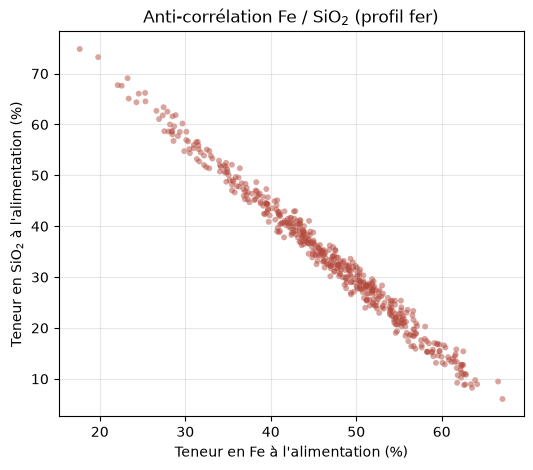

In [7]:
plot_fe_sio2_anticorrelation(df_iron);

## Profil 2-Minerai polymétallique réfractaire

La figure signature : la part de l'or piégée dans les sulfures augmente avec la
teneur en sulfures hôtes, et s'aggrave quand le broyage est grossier.

In [9]:
streams_poly = generate_feed("polymetallic_refractory_au", n_samples=500)
df_poly = streams_to_dataframe(streams_poly)
df_poly[["Cu", "Zn", "As", "Co", "Au_gt", "Au_refractory_frac"]].describe().round(2)

,Cu,Zn,As,Co,Au_gt,Au_refractory_frac
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,1.56,2.01,1.11,0.08,4.25,0.78
std,1.81,2.57,1.71,0.06,2.14,0.13
min,0.00,0.00,0.00,0.00,0.51,0.24
25%,0.29,0.20,0.07,0.03,2.47,0.75
50%,0.85,0.88,0.39,0.07,4.33,0.82
75%,2.19,3.05,1.50,0.11,5.94,0.87
max,13.20,16.66,11.11,0.40,8.00,0.95


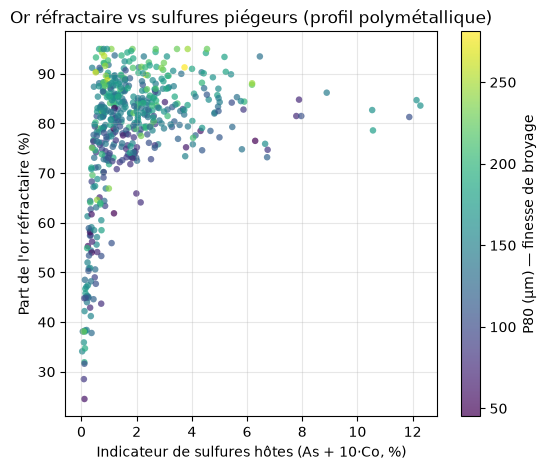

In [10]:
plot_gold_refractory(df_poly);